In [13]:
import easyocr
import cv2
import numpy as np
from utils import convert_to_stats, merge_stats

reader = easyocr.Reader(['en']) # 'en' for English
image_path = "images/minime/1.png"
img = np.array(cv2.imread(image_path))

# # Result format: [bbox, text, confidence]
results = reader.readtext(img)

for (bbox, text, prob) in results:
    print(f"Text: {text}, Confidence: {prob:.2f}, BBox: {bbox}")


Text: Bonus Overview, Confidence: 0.95, BBox: [[np.int32(383), np.int32(219)], [np.int32(765), np.int32(219)], [np.int32(765), np.int32(280)], [np.int32(383), np.int32(280)]]
Text: Healing Speed, Confidence: 1.00, BBox: [[np.int32(100), np.int32(353)], [np.int32(352), np.int32(353)], [np.int32(352), np.int32(409)], [np.int32(100), np.int32(409)]]
Text: 406.80%, Confidence: 0.50, BBox: [[np.int32(867), np.int32(361)], [np.int32(1043), np.int32(361)], [np.int32(1043), np.int32(399)], [np.int32(867), np.int32(399)]]
Text: Troops Attack, Confidence: 0.77, BBox: [[np.int32(99), np.int32(466)], [np.int32(358), np.int32(466)], [np.int32(358), np.int32(518)], [np.int32(99), np.int32(518)]]
Text: 45.89%, Confidence: 0.99, BBox: [[np.int32(893), np.int32(469)], [np.int32(1043), np.int32(469)], [np.int32(1043), np.int32(507)], [np.int32(893), np.int32(507)]]
Text: Troops Defense, Confidence: 1.00, BBox: [[np.int32(100), np.int32(576)], [np.int32(378), np.int32(576)], [np.int32(378), np.int32(626)

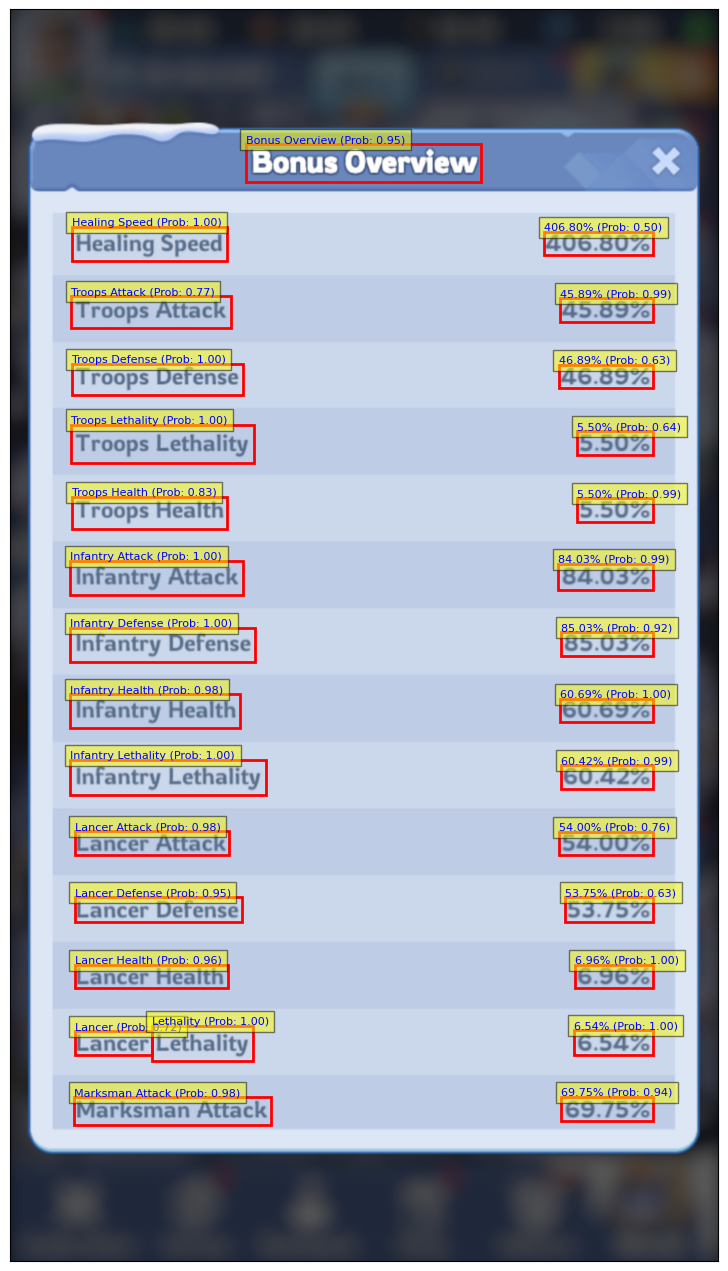

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches


inflated_img = cv2.resize(img, None, fx=4, fy=4, interpolation=cv2.INTER_LINEAR)
img_rgb = cv2.cvtColor(inflated_img, cv2.COLOR_BGR2RGB)

scale_factor = 4
height, width, _ = img_rgb.shape
dpi = 500
fig_width = width / dpi
fig_height = height / dpi

fig, ax = plt.subplots(1, figsize=(fig_width, fig_height))
ax.imshow(img_rgb)



for (bbox, text, prob) in results:
    # Scale the bbox coordinates
    scaled_bbox = []
    for point in bbox:
        scaled_bbox.append([point[0] * scale_factor, point[1] * scale_factor])

    x_coords = [point[0] for point in scaled_bbox]
    y_coords = [point[1] for point in scaled_bbox]

    x = min(x_coords)
    y = min(y_coords)
    width = max(x_coords) - min(x_coords)
    height = max(y_coords) - min(y_coords)

    # Create a Rectangle patch
    rect = patches.Rectangle((x, y), width, height,
                                linewidth=2, edgecolor='r', facecolor='none')

    # Add the rectangle to the axes
    ax.add_patch(rect)

    # Add the text and confidence score
    # Adjust text position based on scaled coordinates
    ax.text(x, y - 10, f"{text} (Prob: {prob:.2f})",
            color='blue', fontsize=8, bbox=dict(facecolor='yellow', alpha=0.5))
            # You might want to scale fontsize as well for readability on a larger image
            # Or adjust it manually based on what looks good
# Hide the axes ticks
ax.set_xticks([])
ax.set_yticks([])

# Display the image with annotations
plt.show()


In [16]:
stats = convert_to_stats(results)
print(stats)


{'infantry': [129.92000000000002, 131.92000000000002, 60.42, 60.69], 'lancers': [99.89, 100.64, 6.54, 6.96], 'marksmen': [115.64, 46.89, 0.0, 0.0]}


In [1]:
import base64
image_path_1 = "images/minime/1.png"
image_path_2 = "images/minime/2.png"
with open(image_path_1, "rb") as img_file:
    image_data_1 = base64.b64encode(img_file.read()).decode('utf-8')
with open(image_path_2, "rb") as img_file:
    image_data_2 = base64.b64encode(img_file.read()).decode('utf-8')


In [5]:
import cv2
import numpy as np
idata1 = base64.b64decode(image_data_1)
cv2.imdecode(np.frombuffer(idata1, np.uint8), cv2.IMREAD_COLOR)


array([[[45, 40, 38],
        [46, 42, 39],
        [48, 42, 41],
        ...,
        [28, 20, 16],
        [27, 20, 16],
        [26, 20, 16]],

       [[46, 40, 39],
        [47, 42, 40],
        [48, 43, 41],
        ...,
        [28, 20, 16],
        [27, 20, 16],
        [26, 20, 16]],

       [[46, 41, 39],
        [47, 42, 40],
        [48, 43, 41],
        ...,
        [28, 20, 16],
        [27, 20, 16],
        [26, 20, 16]],

       ...,

       [[46, 31, 25],
        [47, 32, 25],
        [48, 33, 26],
        ...,
        [52, 42, 38],
        [51, 42, 38],
        [49, 41, 37]],

       [[46, 31, 25],
        [47, 32, 25],
        [48, 33, 26],
        ...,
        [51, 42, 38],
        [50, 41, 37],
        [49, 40, 36]],

       [[46, 31, 25],
        [47, 32, 25],
        [48, 33, 25],
        ...,
        [51, 41, 37],
        [50, 40, 36],
        [49, 39, 35]]], shape=(2032, 1150, 3), dtype=uint8)